In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
from tsp import AnnealingSolver
from mst_prim import prim_mst, createRoutes
from leach import LeachSolver
from nemo import evaluate_nemo
import util
from util import lighten_color
import seaborn as sns
from util import centroid_label, ch_label, coordinator_label, worker_label, ccolor, cmarker
from topology import get_lognorm_hist
import topology

#### Topology Setup

In [2]:
seed = 4
np.random.seed(seed)

avg = 20
c_capacity = 20

H, bins = get_lognorm_hist()
# coords_df = topology.coords_fit_energy(path=topology.path_ENERGY_COORDS_tp2_classic)
# coords_df = topology.coords_fit_energy(path=topology.path_ENERGY_COORDS_tp2_height)
# coords_df = topology.coords_fit_energy(path=topology.path_ENERGY_COORDS_tp2_gateway_classic)
# coords_df = topology.coords_fit_energy(path=topology.path_ENERGY_COORDS_tp2_gateway_height)
# coords_df = topology.coords_fit_energy(path=topology.path_ENERGY_COORDS_tp2_receiver_classic)
coords_df = topology.coords_fit_energy(path=topology.path_ENERGY_COORDS_tp2_receiver_height)
coord_dict = {"energy_tp2": coords_df}
device_number = coords_df.shape[0]
max_resources = device_number * avg - c_capacity

df_dict_topologies = topology.create_topologies_from_dict(coord_dict, H, max_resources, c_capacity,
                                                          weights=(1, avg * 2), dist="lognorm", with_clustering=True,
                                                          kmin=4, kmax=15, kseed=10)

sigma: [1.41161381] scale: [7.33497171]
Creating df for energy_tp2
Optimal k is 4
Done


In [3]:
t_label = "energy_tp2"
prim_df, c_coords, base_col, slot_columns, centroids, opt_k, sil = df_dict_topologies[t_label]
prim_df["weight_1"] = 1
prim_df["weight_2"] = 2
coords = prim_df[["x", "y"]].to_numpy()

eval_matrix = {}
prim_df

,x,y,latency,type,base,weight,capacity_100,capacity_90,capacity_80,capacity_70,...,capacity_50,capacity_40,capacity_30,capacity_20,capacity_10,capacity_5,capacity_1,cluster,weight_1,weight_2
0,397.985807,88.552314,0.000000,coordinator,7056,0,20,20,20,20,...,20,20,20,20,20,20,20,-1,1,2
1,419.809247,9.815085,81.705654,worker,7056,12,20,20,21,19,...,26,14,16,11,12,29,24,0,1,2
2,387.092359,80.544943,13.519807,worker,7056,1,20,20,20,21,...,20,24,27,11,33,6,8,0,1,2
3,350.425987,89.466675,47.568609,worker,7056,2,20,21,19,23,...,22,14,22,38,29,10,10,0,1,2
4,392.667450,27.248525,61.534051,worker,7056,3,20,22,23,18,...,20,16,30,10,11,17,123,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,122.908364,86.930480,275.082224,worker,7056,12,20,22,22,18,...,28,17,15,12,14,6,5,1,1,2
80,196.608939,66.487774,202.582049,worker,7056,5,20,20,22,22,...,20,29,14,19,10,11,4,2,1,2
81,154.717825,83.272823,243.325263,worker,7056,2,20,21,20,22,...,26,18,14,12,8,54,13,1,1,2
82,107.771432,88.620839,290.214383,worker,7056,1,20,21,21,22,...,20,21,15,11,26,13,0,1,1,2


In [4]:
# prepare rtts
# prim_rtts = topology.energy_fit(path=topology.path_ENERGY_tp2) # reale consumption
# prim_rtts = topology.energy_fit(path=topology.path_ENERGY_tp2_gateway) # reale consumption
prim_rtts = topology.energy_fit(path=topology.path_ENERGY_tp2_receiver) # reale consumption
for i in range(prim_rtts.shape[0]):
    for j in range(prim_rtts.shape[0]):
        lat = prim_rtts.loc[i, j]
        if i != j and lat == 0:
            prim_rtts.loc[i, j] = int(np.linalg.norm(coords[i] - c_coords))

In [5]:
from util import euclidean_distance
dist = euclidean_distance(prim_df.loc[5,["x","y"]].to_numpy(), prim_df.loc[6,["x","y"]].to_numpy())
dist_real = prim_rtts.at[5,6]
print(dist, dist_real)

dist = euclidean_distance(prim_df.loc[50,["x","y"]].to_numpy(), prim_df.loc[60,["x","y"]].to_numpy())
dist_real = prim_rtts.at[50,60]
print(dist, dist_real)

118.67842320937972 194.6
21.128673540983012 194.6


In [6]:
prim_rtts

,0,1,2,3,4,5,6,7,8,9,...,74,75,76,77,78,79,80,81,82,83
0,0.0,194.6,194.6,195.1,194.6,196.5,199.9,196.5,196.5,197.5,...,391.6,397.1,398.4,396.8,401.6,397.8,401.6,397.8,402.2,397.8
1,194.6,0.0,194.6,194.6,194.6,197.5,197.5,195.1,195.1,199.2,...,393.7,399.7,401.0,207.0,402.1,400.4,207.0,400.4,404.8,400.4
2,194.6,194.6,0.0,194.6,194.6,195.1,195.1,198.5,196.5,198.5,...,401.6,400.8,402.1,202.2,207.0,401.4,207.0,401.6,401.6,401.4
3,195.1,194.6,194.6,0.0,194.6,196.5,195.1,199.2,198.5,199.9,...,202.2,397.8,399.1,199.9,203.7,398.2,202.2,398.2,398.2,398.2
4,194.6,194.6,194.6,194.6,0.0,197.5,196.5,197.5,196.5,198.5,...,206.1,400.7,400.7,207.0,402.1,400.7,207.0,402.1,401.6,402.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,405.5,406.2,406.2,402.1,398.8,401.6,399.5,401.6,400.0,407.6,...,195.1,194.6,194.6,195.1,194.6,0.0,194.6,194.6,194.6,194.6
80,401.2,401.6,400.7,206.1,203.7,205.4,204.9,207.0,205.4,402.1,...,194.6,195.1,195.1,194.6,194.6,194.6,0.0,195.1,194.6,195.1
81,402.6,404.7,401.6,400.7,398.2,207.0,401.6,401.6,401.6,402.1,...,194.6,194.6,194.6,195.1,194.6,194.6,194.6,0.0,194.6,194.6
82,405.5,406.2,401.6,401.6,398.2,401.6,399.5,401.6,400.0,596.7,...,194.6,194.6,194.6,194.6,194.6,194.6,194.6,194.6,0.0,194.6


In [7]:
prim_rtts = prim_rtts

In [8]:
print("Required:", prim_df["weight"].sum(), "Available:", prim_df["capacity_100"].sum())
colors, light_colors, palette = util.get_color_list(opt_k)
palette

Required: 498 Available: 1680


[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392)]

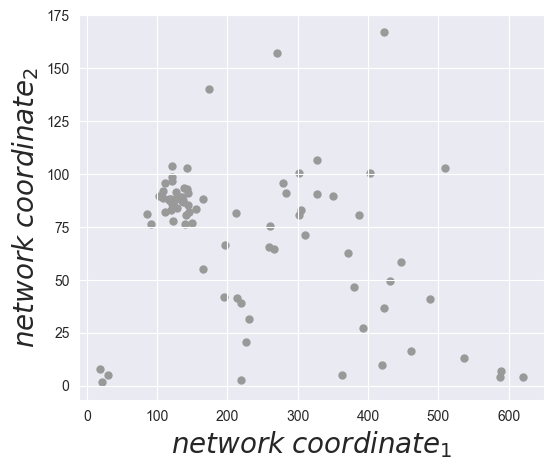

In [9]:
X_dim_def = [-50, 50]
Y_dim_def = [-60, 60]

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))
ax1 = util.plot_topology(ax1, prim_df, show_legend=False, show_coordinator=False)

#ax1.set_xlim(X_dim_def)
#ax2.set_xlim(X_dim_def)

#ax1.set_ylim(Y_dim_def)
#ax2.set_ylim(Y_dim_def)

X_dim = ax1.get_xlim()
Y_dim = ax1.get_ylim()

# plt.savefig("plots/energy/ncs_plain.svg", bbox_inches="tight")

plt.show()

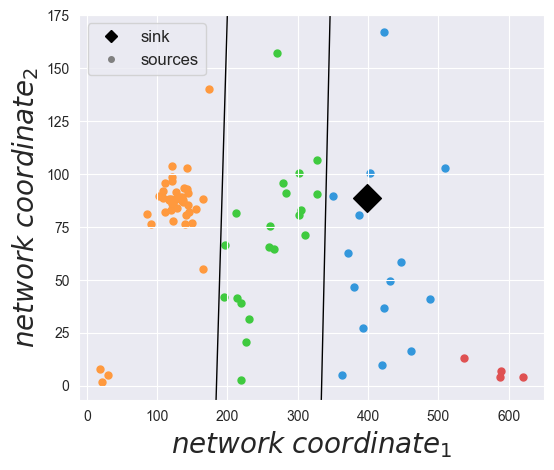

In [10]:
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))

ax1 = util.plot_topology(ax1, prim_df, colors, 'Topology (k=' + str(opt_k) + ")")

ax1.set_xlim(X_dim)
ax1.set_ylim(Y_dim)

# plt.savefig("plots/energy/ncs_colored.svg", bbox_inches="tight")

plt.show()

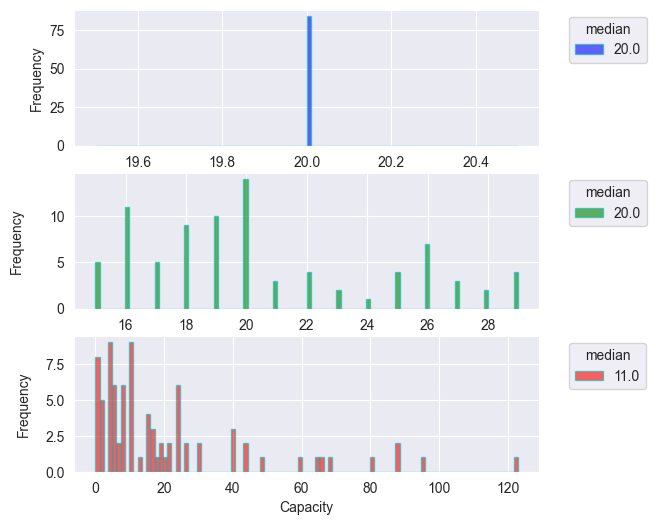

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 6))

i = 100
prim_df["capacity_" + str(i)].plot.hist(ax=ax1, bins=100, alpha=0.6, color='b', ec='c',
                                        label=prim_df["capacity_" + str(i)].median())

i = 50
prim_df["capacity_" + str(i)].plot.hist(ax=ax2, bins=100, alpha=0.6, color='g', ec='c',
                                        label=prim_df["capacity_" + str(i)].median())

i = 1
prim_df["capacity_" + str(i)].plot.hist(ax=ax3, bins=100, alpha=0.6, color='r', ec='c',
                                        label=prim_df["capacity_" + str(i)].median())

ax1.legend(title='median', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.legend(title='median', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.legend(title='median', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.set_xlabel("Capacity")

# Set y-axis label with padding
ax2.set_ylabel("Frequency", labelpad=18)
ax3.set_ylabel("Frequency", labelpad=10)
# plt.savefig(f"plots/sim_1000/capacity_dist_energy.svg", bbox_inches="tight")

plt.show()

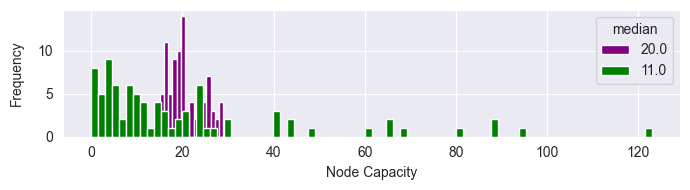

In [12]:
fig, (merged_ax) = plt.subplots(1, 1, figsize=(7, 2))

i = 50
prim_df["capacity_" + str(i)].plot.hist(ax=merged_ax, bins=15, alpha=1, color='purple',
                                        label=prim_df["capacity_" + str(i)].median())

#i = 10
#prim_df["capacity_"+str(i)].plot.hist(ax=merged_ax, bins=40, alpha=1, color='orange', label=prim_df["capacity_"+str(i)].median())

i = 1
prim_df["capacity_" + str(i)].plot.hist(ax=merged_ax, bins=80, alpha=1, color='green',
                                        label=prim_df["capacity_" + str(i)].median())

merged_ax.legend(title='median', loc='upper right')
merged_ax.set_xlabel("Node Capacity")

# Set y-axis label with padding
merged_ax.set_ylabel("Frequency", labelpad=10)

# Set the same x-axis limits for both histograms
xlim = (prim_df["capacity_1"].min(), prim_df["capacity_1"].max())
# merged_ax.set_xlim(xlim)
# merged_ax.set_ylim([0, 250])
#
# merged_ax.yaxis.label.set_size(16)
# merged_ax.xaxis.label.set_size(16)
#merged_ax.tick_params(axis='x', labelsize=20)

# Adjust figure layout for better display
fig.tight_layout()

# plt.savefig(f"plots/energy/capacity_dist.svg", bbox_inches="tight")
plt.show()

Medians from  20  to  11


Text(0.5, 0, 'Slot Diversity Size')

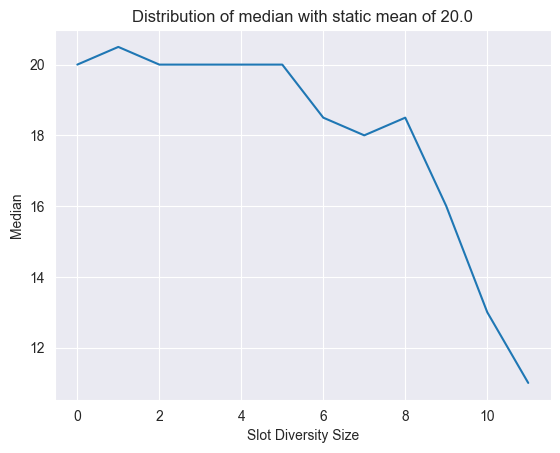

In [13]:
medians = []
mean = np.floor(prim_df["capacity_" + str(1)].mean())

for col in slot_columns:
    medians.append(prim_df[col].median())

medians = np.array(medians)
plt.plot(np.arange(len(medians)), medians)

first_med_label = "20"
last_med_label = "11"
print("Medians from ", first_med_label, " to ", last_med_label)

#print(load_dict)
plt.title("Distribution of median with static mean of " + str(mean))
plt.ylabel("Median")
plt.xlabel("Slot Diversity Size")
# plt.savefig(f"plots/energy/median_distribution.svg", bbox_inches="tight")


### Experiment 1: Send all data directly to coordinator

In [14]:
#first node is the coordinator
latency_hist = np.zeros(device_number)
for i in range(0, device_number):
    #calculate euclidean distance which corresponds to the cost space (latency)
    if prim_rtts is not None:
        lat = prim_rtts.loc[15, i]
    else:
        lat = np.linalg.norm(coords[i] - c_coords)
    latency_hist[i] = float(lat)

received_packets_hist = np.zeros(device_number)
for i in range(1, device_number):
    #coordinator receives 1 packet from each
    received_packets_hist[0] = received_packets_hist[0] + 1

statistics = {"latency_distribution": latency_hist,
              "received_packets": received_packets_hist}
df_stats = pd.DataFrame(statistics, dtype=float)
print(df_stats)
eval_matrix["dt"] = df_stats.copy()

    latency_distribution  received_packets
0                  197.5              83.0
1                  197.5               0.0
2                  393.8               0.0
3                  198.5               0.0
4                  199.2               0.0
..                   ...               ...
79                 598.0               0.0
80                 403.4               0.0
81                 598.6               0.0
82                 598.0               0.0
83                 598.6               0.0

[84 rows x 2 columns]


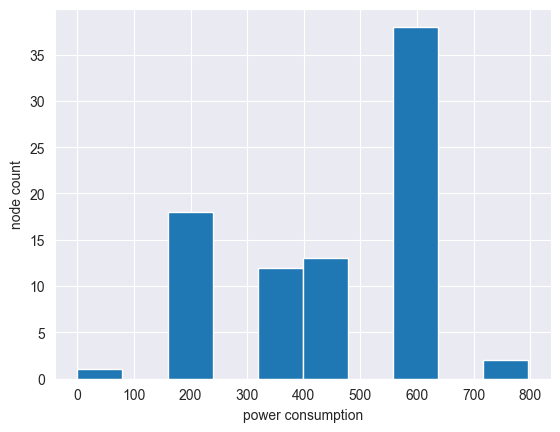

In [15]:
df_stats["latency_distribution"].hist()
plt.xlabel("power consumption")
plt.ylabel("node count")
# plt.title("Power Consumption Distribution")
# plt.savefig(f"plots/energy/direct_coordinator_distribution.svg", bbox_inches="tight")
plt.show()

In [16]:
df_packets = df_stats.loc[df_stats["received_packets"] > 0]["received_packets"]
print("Distribution of workload: ", 1, "/", device_number, "=", round(len(df_packets) / device_number * 100, 5), "%")

Distribution of workload:  1 / 84 = 1.19048 %


### Experiment 1: LEACH Protocol

In [17]:
seed = 10
np.random.seed(seed)
latency_hist_sum = None
received_packets_hist_sum = None
leach_runs = 20
run = 1
df_stats_leach = []
num_leach_clusters = int(0.1 * device_number)

for i in range(leach_runs):
    print("LEACH run", run)
    if run == leach_runs:
        leachSolver = LeachSolver(prim_df, num_leach_clusters, coords, seed=seed)
    else:
        leachSolver = LeachSolver(prim_df, num_leach_clusters, coords)

    leach_labels, ch_indexes, latency_hist, received_packets_hist = leachSolver.leachClustering(df_rtt=prim_rtts,
                                                                                                rtt_eval=True,
                                                                                                rtt_clustering=True)

    if latency_hist_sum is None:
        latency_hist_sum = latency_hist
    else:
        latency_hist_sum = latency_hist_sum + latency_hist

    statistics = {"latency_distribution": latency_hist,
                  "received_packets": received_packets_hist}
    df_stats = pd.DataFrame(statistics)
    df_stats_leach.append(df_stats.copy())
    run = run + 1

print("Number of clusters = ", len(ch_indexes))
print(ch_indexes)

LEACH run 1
LEACH run 2
LEACH run 3
LEACH run 4
LEACH run 5
LEACH run 6
LEACH run 7
LEACH run 8
LEACH run 9
LEACH run 10
LEACH run 11
LEACH run 12
LEACH run 13
LEACH run 14
LEACH run 15
LEACH run 16
LEACH run 17
LEACH run 18
LEACH run 19
LEACH run 20
Number of clusters =  8
[74, 5, 55, 62, 83, 2, 27, 60]


In [18]:
df_stats

,latency_distribution,received_packets
0,0.0,8.0
1,389.2,0.0
2,194.6,3.0
3,389.2,0.0
4,389.2,0.0
...,...,...
79,592.4,0.0
80,586.2,0.0
81,586.2,0.0
82,586.2,0.0


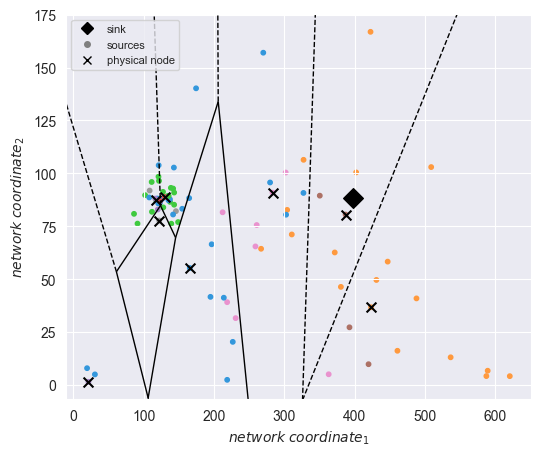

In [19]:
fig = plt.figure(figsize=(6, 5)).gca()
cluster_head_coords = coords[ch_indexes]

leach_color_list = sns.color_palette(n_colors=num_leach_clusters)
leach_colors = np.asarray(leach_color_list.as_hex())

fig.scatter(coords[0, 0], coords[0, 1], s=100, color=ccolor, marker=cmarker, zorder=100)
fig.scatter(cluster_head_coords[:, 0], cluster_head_coords[:, 1], s=50, color="black", marker="x", zorder=2)
fig.scatter(coords[:, 0], coords[:, 1], s=10, color=[lighten_color(x, 0.8) for x in leach_colors[leach_labels]],
            zorder=-1)

plt.legend(handles=[coordinator_label, worker_label, ch_label], loc="upper left", bbox_to_anchor=(0, 1), fontsize=8)

vor = Voronoi(cluster_head_coords)
voronoi_plot_2d(vor, ax=fig, point_size=16, color="red", show_vertices=False, show_points=False)

plt.xlabel('$network$ $coordinate_1$')
plt.ylabel('$network$ $coordinate_2$')
plt.xlim(X_dim)
plt.ylim(Y_dim)
# plt.savefig(f"plots/energy/leach.svg")
plt.show()

count     84.000000
mean     493.471429
std      123.555778
min        0.000000
25%      394.000000
50%      586.200000
75%      590.700000
max      594.800000
Name: latency_distribution, dtype: float64


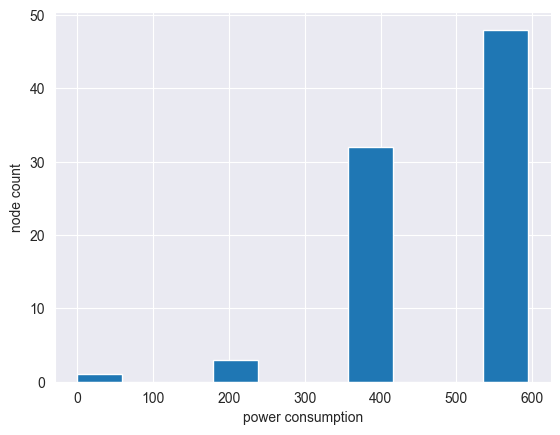

In [20]:
df_stats["latency_distribution"].hist()
plt.xlabel("power consumption")
plt.ylabel("node count")
# plt.title("Power Consumption Distribution Leach")
# plt.savefig(f"plots/energy/leach_distribution.svg", bbox_inches="tight")
print(df_stats["latency_distribution"].describe())

In [21]:
eval_matrix["leach"] = df_stats.copy()

Distribution of workload:  10.7143 %


Text(0, 0.5, 'processed packets')

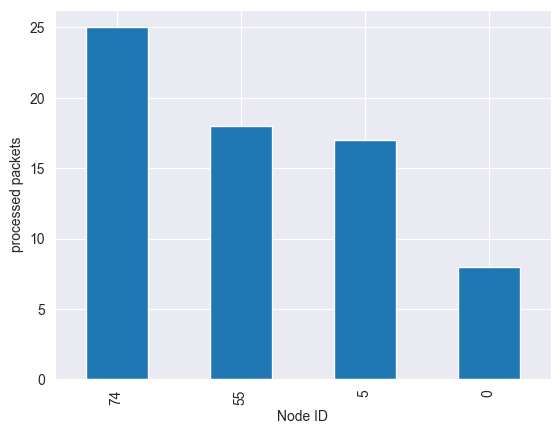

In [22]:
df_packets = df_stats.loc[df_stats["received_packets"] > 0]["received_packets"].sort_values(ascending=False)
print("Distribution of workload: ", round(len(df_packets) / device_number * 100, 4), "%")

df_packets = df_packets.head(int(round(device_number * 0.05)))
df_packets.plot.bar()

plt.xlabel("Node ID")
plt.ylabel("processed packets")
# plt.savefig(f"plots/energy/leach_processed_packets_distribution.svg", bbox_inches="tight")

### Experiment 2a: NEMO Aggregation with Density-based Grouping

### Identify parameters

In [23]:
# fixed params
skip = True
max_levels = 50
slot_col = "capacity_100"
weight_col = "weight"

# dynamic params
num_points = 9
start = 0.1
end = 0.9
hyperparam_values_1 = np.linspace(start, end, num_points)
hyperparam_values_2 = np.linspace(start, end, num_points)
X, Y = np.meshgrid(hyperparam_values_1, hyperparam_values_2)

# Initialize an array to store performance values
perc_lat_values = np.full_like(X, fill_value=np.nan)
mean_lat_values = np.full_like(X, fill_value=np.nan)

for i in range(num_points):
    if skip:
        break
    for j in range(num_points):
        eval_dict, df_dict, opt_dict, limits_dict = evaluate_nemo(prim_df, [slot_col], weight_col, merge_factor=X[i, j],
                                                                  step_size=Y[i, j], max_levels=max_levels,
                                                                  with_eval=True, df_rtt=prim_rtts)
        if limits_dict[slot_col]:
            continue

        sv = eval_dict[slot_col]["latency_distribution"].sort_values()
        perc_lat = round(sv.quantile(0.9), 2)
        mean_lat = round(sv.mean(), 2)
        print(perc_lat, mean_lat)

        perc_lat_values[i, j] = perc_lat
        mean_lat_values[i, j] = mean_lat

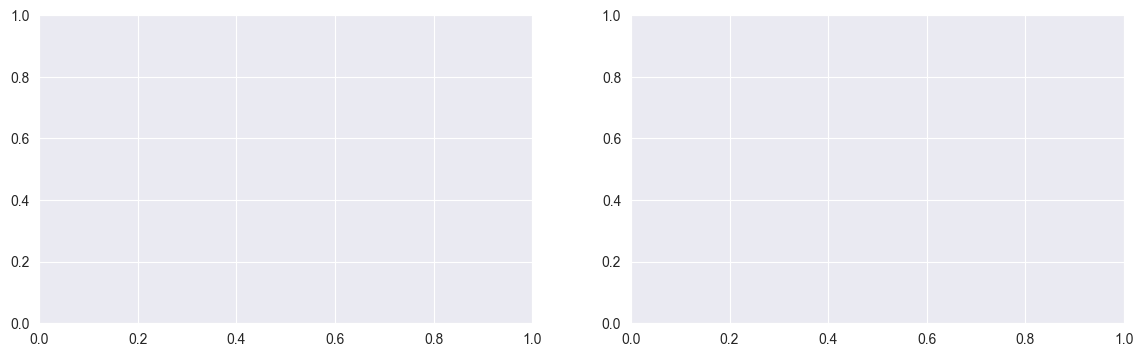

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

for i, values in enumerate([perc_lat_values, mean_lat_values]):
    if skip:
        break
    if i == 0:
        label = "power consumption (90P)"
    elif i == 1:
        label = "power consumption (mean)"
    else:
        label = "undefined"

    # Find the indices of the minimum Z value, ignoring nans
    min_index = np.unravel_index(np.nanargmin(values), values.shape)
    # Use the indices to get the corresponding X and Y values
    min_X = X[min_index]
    min_Y = Y[min_index]
    print(f"merge factor and step size for minimum {label}: (X={min_X}, Y={min_Y})", values[min_index])

    # Create a contour plot
    ax = axs[i]
    contour = ax.contourf(X, Y, values, levels=80, cmap='viridis')

    # Create a colorbar and set the label
    colorbar = plt.colorbar(contour)
    colorbar.set_label(label)

    ax.set_title(f"Performance {label}")
    ax.set_xlabel('merge factor')
    ax.set_ylabel('step size')

# plt.savefig(f"plots/energy/nemop_params_sl_{slot_col}_w_{weight_col}.svg", bbox_inches="tight")
plt.show()

In [25]:
param_dict = {
    "weight_1": {"merge_factor": 0.5, "step_size": 0.3}, # what is capacity here?
    "weight_2": {"merge_factor": 0.6, "step_size": 0.25},
    "weight": {"merge_factor": 0.55, "step_size": 0.45},

    "capacity_100": {
        "weight_1": {"merge_factor": 0.5, "step_size": 0.6},
        "weight_2": {"merge_factor": 0.6, "step_size": 0.2},
        "weight": {"merge_factor": 0.85, "step_size": 0.2}
    },
    "capacity_1": {
        "weight_1": {"merge_factor": 0.5, "step_size": 0.5},
        "weight_2": {"merge_factor": 0.5, "step_size": 0.45},
        "weight": {"merge_factor": 0.6, "step_size": 0.31}
    }
}

param_dict_filtered = {
    "weight_1": {"merge_factor": 0.1, "step_size": 0.3}, # what is capacity here?
    "weight_2": {"merge_factor": 0.1, "step_size": 0.3},
    "weight": {"merge_factor": 0.4, "step_size": 0.3},

    "capacity_100": {
        "weight_1": {"merge_factor": 0.5, "step_size": 0.3},
        "weight_2": {"merge_factor": 0.45, "step_size": 0.45},
        "weight": {"merge_factor": 0.3, "step_size": 0.59}
    },
    "capacity_1": {
        "weight_1": {"merge_factor": 0.5, "step_size": 0.3},
        "weight_2": {"merge_factor": 0.5, "step_size": 0.25},
        "weight": {"merge_factor": 0.8, "step_size": 0.21}
    }
}

param_dict = param_dict_filtered

plt.show()

In [26]:
# for the eval for weights regarding latency
weight_cols = ["weight_1", "weight_2", "weight"]

for weight_col in weight_cols:
    eval_name = "nemo_dc" + "_" + weight_col
    eval_matrix[eval_name], df_dict, opt_dict, limits_dict = evaluate_nemo(prim_df, ["capacity_100", "capacity_1"],
                                                                           weight_col,
                                                                           merge_factor=param_dict[weight_col][
                                                                               "merge_factor"],
                                                                           step_size=param_dict[weight_col][
                                                                               "step_size"], with_eval=True,
                                                                           df_rtt=prim_rtts)

Starting nemo for: c=capacity_100, w=weight_1, l=20, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 83
--------Balancing load for 4 clusters to 0
Level 1 CH number:  7 Load: 7
Evaluating for capacity_100
Starting nemo for: c=capacity_1, w=weight_1, l=20, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 83
--------Balancing load for 4 clusters to 0
Level 1 CH number:  10 Load: 10
Evaluating for capacity_1
Starting nemo for: c=capacity_100, w=weight_2, l=20, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 166
--------Balancing load for 4 clusters to 0
Level 1 CH number:  11 Load: 22
--------Balancing load for 1 clusters to 0
Level 2 CH number:  2 Load: 4
Evaluating for capacity_100
Starting nemo for: c=capacity_1, w=weight_2, l=20, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 166
--------Balancing load for 4 clusters to 0
Level 1 CH number:  14 Load: 28
--------Balancing load for 1 clusters to 0
Level 2 CH number:  5 Load: 10
Evaluat

In [27]:
# for the plots and vanilla NEMO
slot_col = "capacity_100"
weight_col = "weight_1"
eval_name = "nemo_dc_" + weight_col
df_dict_1, opt_dict_1, limits_dict_1 = evaluate_nemo(prim_df, [slot_col], weight_col, max_levels=1,
                                                     merge_factor=param_dict[weight_col]["merge_factor"],
                                                     step_size=param_dict[weight_col]["step_size"], with_eval=False)

# for the load evaluation
eval_matrix[eval_name], df_dict, opt_dict, limits_dict = evaluate_nemo(prim_df, slot_columns, weight_col,
                                                                       merge_factor=param_dict[weight_col][
                                                                           "merge_factor"],
                                                                       step_size=param_dict[weight_col]["step_size"],
                                                                       with_eval=True, df_rtt=prim_rtts)

Starting nemo for: c=capacity_100, w=weight_1, l=1, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 83
--------Balancing load for 4 clusters to 0
Level 1 CH number:  7 Load: 7
Starting nemo for: c=capacity_100, w=weight_1, l=20, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 83
--------Balancing load for 4 clusters to 0
Level 1 CH number:  7 Load: 7
Evaluating for capacity_100
Starting nemo for: c=capacity_90, w=weight_1, l=20, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 83
--------Balancing load for 4 clusters to 0
Level 1 CH number:  7 Load: 7
Evaluating for capacity_90
Starting nemo for: c=capacity_80, w=weight_1, l=20, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 83
--------Balancing load for 4 clusters to 0
Level 1 CH number:  7 Load: 7
Evaluating for capacity_80
Starting nemo for: c=capacity_70, w=weight_1, l=20, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 83
--------Balancing load for 4 clusters to 0
Le

In [28]:
df = df_dict[slot_col]
df

,oindex,x,y,type,cluster,total_weight,unbalanced_weight,used_weight,total_capacity,free_capacity,level,parent,load
0,0,397.985807,88.552314,coordinator,-1,<NA>,<NA>,<NA>,20,13,2,<NA>,7
1,1,419.809247,9.815085,worker,0,1,0,1,20,20,0,2,0
2,2,387.092359,80.544943,worker,0,1,0,1,20,6,1,0,14
3,3,350.425987,89.466675,worker,0,1,0,1,20,20,0,2,0
4,4,392.667450,27.248525,worker,0,1,0,1,20,20,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,79,122.908364,86.930480,worker,1,1,0,1,20,20,0,80,0
80,80,196.608939,66.487774,worker,2,1,0,1,20,2,1,0,18
81,81,154.717825,83.272823,worker,1,1,0,1,20,20,0,65,0
82,82,107.771432,88.620839,worker,1,1,0,1,20,20,0,20,0


In [29]:
df[df["parent"] == 0]

,oindex,x,y,type,cluster,total_weight,unbalanced_weight,used_weight,total_capacity,free_capacity,level,parent,load
2,2,387.092359,80.544943,worker,0,1,0,1,20,6,1,0,14
19,19,536.614950,13.075896,worker,3,1,0,1,20,17,1,0,3
20,20,212.175758,81.612130,worker,2,1,0,1,20,2,1,0,18
25,25,303.979797,82.739790,worker,2,1,0,1,20,18,1,0,2
32,32,302.466835,80.471401,worker,2,1,0,1,20,6,1,0,14
65,65,164.591477,88.314458,worker,1,1,0,1,20,13,1,0,7
80,80,196.608939,66.487774,worker,2,1,0,1,20,2,1,0,18


In [30]:
# check -> should be empty
df_overloaded = df.groupby(['parent'])['used_weight'].sum().copy().reset_index()
df_join = df[["oindex", "total_capacity", "free_capacity"]]
result = pd.merge(df_join, df_overloaded, left_on='oindex', right_on='parent', how='inner')
result["delta"] = result["total_capacity"] - result["used_weight"]
result[result["delta"] < 0]

,oindex,total_capacity,free_capacity,parent,used_weight,delta


In [31]:
# check -> should be empty
result[result["delta"] != result["free_capacity"]]

,oindex,total_capacity,free_capacity,parent,used_weight,delta


In [32]:
result

,oindex,total_capacity,free_capacity,parent,used_weight,delta
0,0,20,13,0,7,13
1,2,20,6,2,14,6
2,19,20,17,19,3,17
3,20,20,2,20,18,2
4,25,20,18,25,2,18
5,32,20,6,32,14,6
6,65,20,13,65,7,13
7,80,20,2,80,18,2


In [33]:
#create greedy aggregation tree
cluster_coords = centroids
cluster_coords_with_crd = np.column_stack((c_coords, cluster_coords.T)).T

mst = prim_mst(cluster_coords_with_crd)

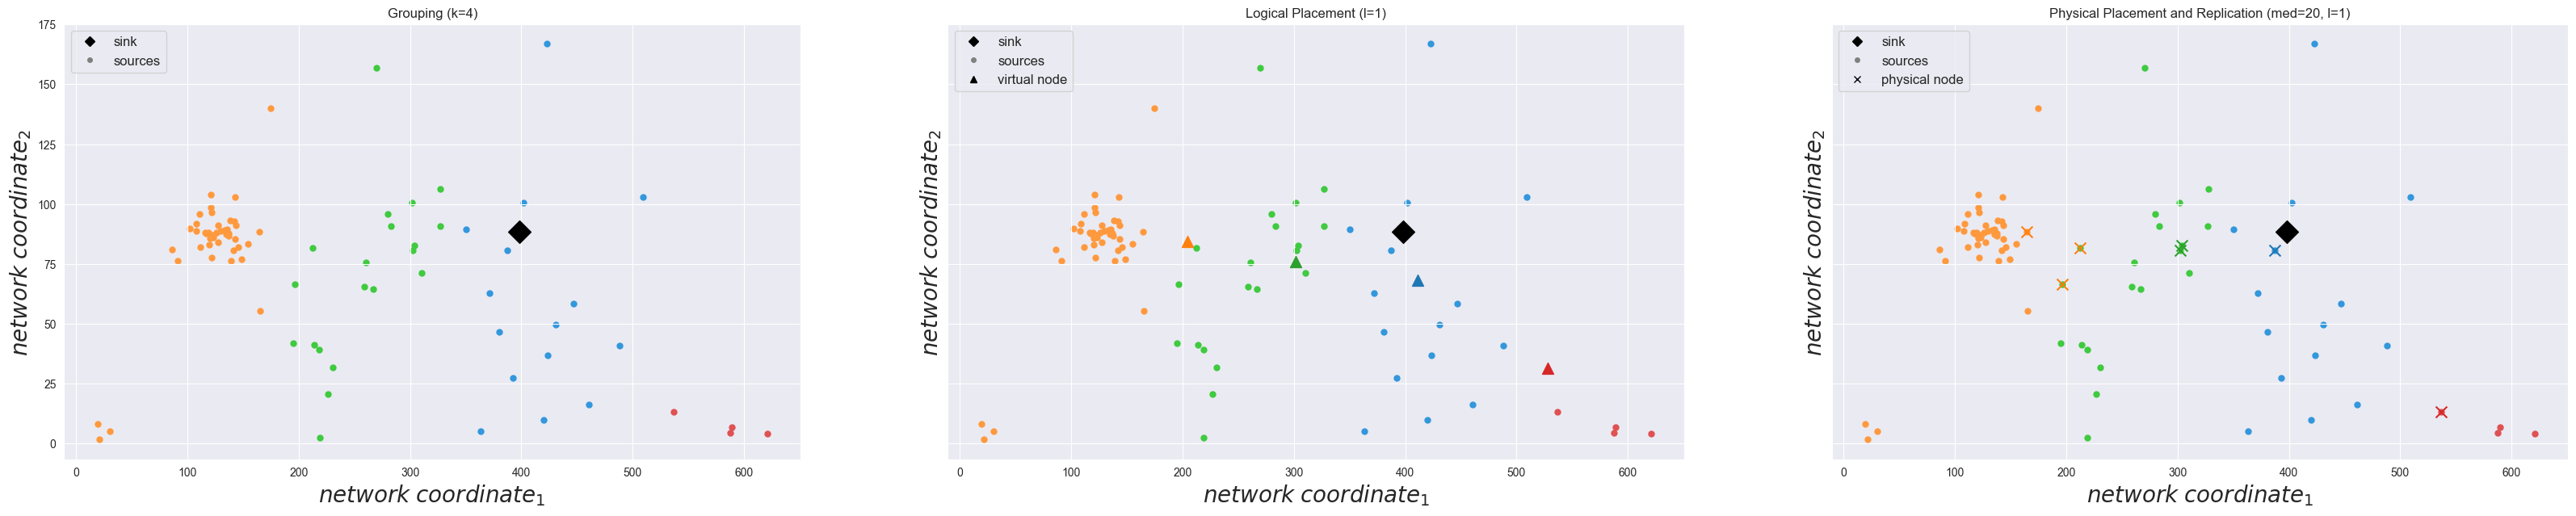

In [34]:
fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(40, 7), sharex="all", sharey="all")

lval = 0.8
leg_size = 12
symbol_size = 100
scale_fac = 0.25
axis_label_size = 20

labels = prim_df["cluster"]

# plot greedy approach from MST
for i in range(1, len(mst)):
    point1 = cluster_coords_with_crd[i]
    point2 = cluster_coords_with_crd[mst[i]]
    x_values = [point1[0], point2[0]]
    y_values = [point1[1], point2[1]]
    ax1.plot(x_values, y_values, zorder=2, color=colors[i - 1])

ax1.scatter(coords[0, 0], coords[0, 1], s=2 * symbol_size, color=ccolor, marker=cmarker, zorder=10)
ax1.scatter(cluster_coords[:, 0], cluster_coords[:, 1], s=symbol_size, color=colors[:len(cluster_coords)], zorder=3)
# in case all coords shall be plotted
ax1.scatter(coords[:, 0], coords[:, 1], s=scale_fac * symbol_size,
            color=[lighten_color(x, lval) for x in colors[labels]])

lcentroid = Line2D([], [], color="blue", marker='o', linestyle='None', label='centroid')
ax1.legend(handles=[coordinator_label, worker_label, centroid_label], loc="upper left", bbox_to_anchor=(0, 1),
           fontsize=leg_size)

ax1.set_xlabel('$network$ $coordinate_1$', fontsize=axis_label_size)
ax1.set_ylabel('$network$ $coordinate_2$', fontsize=axis_label_size)
ax1.set_title('Greedy Aggregation')

#plot grouping
util.plot_topology(ax2, prim_df, colors, title='Grouping (k=' + str(opt_k) + ")", plot_voronoi=False, leg_size=leg_size,
                   symbol_size=symbol_size, scale_fac=scale_fac, axis_label_size=axis_label_size)

#plot logical nodes (optima) of different groups
# util.plot2(ax3, prim_df, df_dict[slot_col], colors, lval=lval, show_centroids=True)
util.plot_optimum(ax3, prim_df, opt_dict[slot_col], colors, lval=lval, plot_centroid=False, plot_lines=False,
                  leg_size=leg_size, symbol_size=symbol_size, scale_fac=scale_fac, axis_label_size=axis_label_size)
# plot physical nodes
util.plot(ax4, prim_df, df_dict_1[slot_col], colors, lval=lval, plot_centroids=False, plot_lines=False,
          leg_size=leg_size, symbol_size=symbol_size, scale_fac=scale_fac, axis_label_size=axis_label_size)

plt.xlim(X_dim)
plt.ylim(Y_dim)
ax3.set_title("Logical Placement (l=1)")
ax4.set_title("Physical Placement and Replication (med=" + first_med_label + ", l=1)")

# plt.savefig(f"plots/energy/nemo_phases.svg", bbox_inches="tight")
plt.show()

Starting nemo for: c=capacity_100, w=weight_2, l=1, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 166
--------Balancing load for 4 clusters to 0
Level 1 CH number:  11 Load: 22
final assignment ------------------Load reached 0 -2
Starting nemo for: c=capacity_100, w=weight_2, l=2, step_size=0.3, merge_factor=0.1
Level 0 CH number:  83 Load: 166
--------Balancing load for 4 clusters to 0
Level 1 CH number:  11 Load: 22
--------Balancing load for 1 clusters to 0
Level 2 CH number:  2 Load: 4


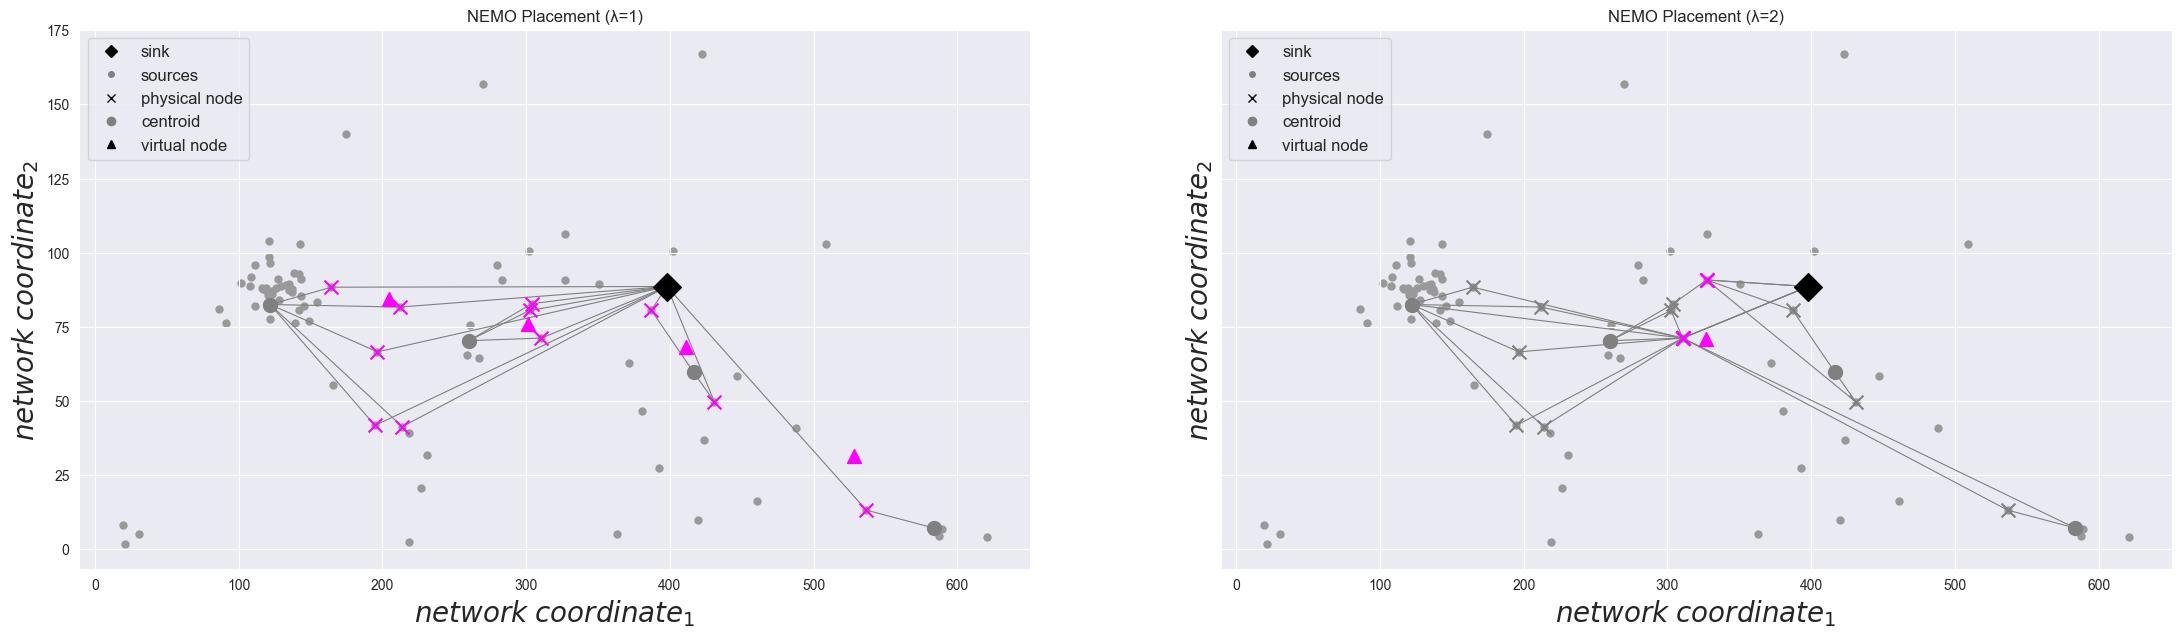

In [76]:
levels = [1, 2]
fig, axs = plt.subplots(1, 2, figsize=(27, 7), sharex="all", sharey="all")
lval = 0.8
weight_col_plot = "weight_2"
slot_col_plot = "capacity_100"
single_color = "grey"

# util.plot_topology(axs[0], prim_df, None, title='Grouping (k=' + str(opt_k) + ")", plot_voronoi=False,
#                    plot_centroid=True, leg_size=leg_size,
#                    symbol_size=symbol_size, scale_fac=scale_fac, axis_label_size=axis_label_size,
#                    point_color=single_color, centroid_color=single_color)

for i, level in enumerate(levels):
    df_dict_i, opt_dict_i, limits_dict_i = evaluate_nemo(prim_df, [slot_col_plot], weight_col_plot,
                                                         merge_factor=param_dict[weight_col_plot]["merge_factor"],
                                                         step_size=param_dict[weight_col_plot]["step_size"],
                                                         max_levels=level, with_eval=False)

    util.plot_with_single_color(axs[i], prim_df, df_dict_i[slot_col_plot], single_color,
                                opt_dict=opt_dict_i[slot_col_plot], leg_size=leg_size, symbol_size=symbol_size,
                                scale_fac=scale_fac, axis_label_size=axis_label_size, lval=lval, plot_centroids=True,
                                plot_lines=True, highlight_color="magenta")
    axs[i].set_title(f"NEMO Placement (λ={str(level)})")
plt.xlim(X_dim)
plt.ylim(Y_dim)
plt.savefig(f"plots/energy/nemo_placement_λ.svg", bbox_inches="tight")
plt.show()

Text(0, 0.5, '$network$ $coordinate_2$')

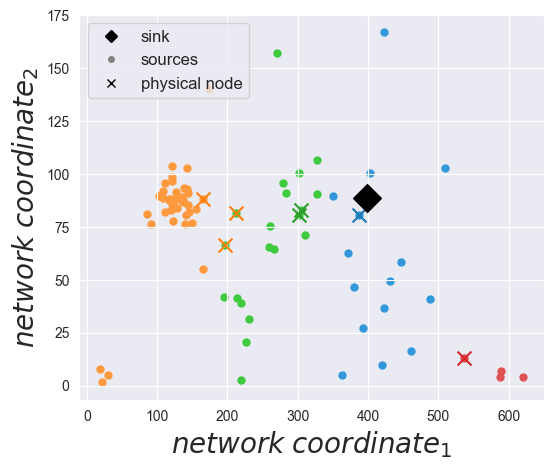

In [36]:
ax = plt.figure(figsize=(6, 5)).gca()

#uncomment this to plot nemo grouping
#ax2.scatter(coords[:, 0], coords[:, 1], s=10, color=[lighten_color(x, 0.2) for x in colors[labels]], zorder=-1)
#ax2.scatter(cluster_coords[:, 0], cluster_coords[:, 1], s=50, color=colors[:no_clusters], zorder=2)
#ax2.scatter(coords[0, 0], coords[0, 1], s=100, color=ccolor, marker=cmarker, zorder=1)
#ax2.set_title('Grouping (k=' + str(opt_k) + ")")
#fig.legend(handles=[coordinator_label, worker_label, centroid_label], loc="upper left", bbox_to_anchor=(0, 1), fontsize=8)

#uncomment this for nemo placement
util.plot(ax, prim_df, df_dict_1[slot_col], colors, lval=0.8, plot_centroids=False, plot_lines=False)

#uncomment this for nemo redistribution
#util.plot(fig, new_paths_flat[slot_col], agg_dict_flat[slot_col], c_coords, cluster_coords, coords, colors, labels, changed_labels=reassigned_clussters, lval=lval)


ax.set_xlabel('$network$ $coordinate_1$')
ax.set_ylabel('$network$ $coordinate_2$')

# plt.savefig(f"plots/energy/nemo_placement.svg", bbox_inches="tight")

Distribution of workload:  11.9048 %


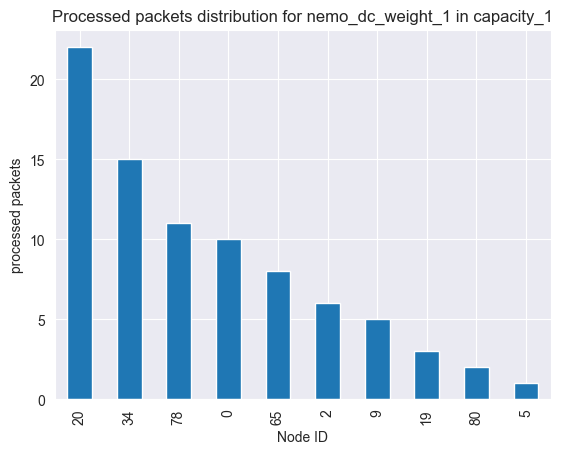

In [37]:
eval_col = list(eval_matrix[eval_name])[-1]
df_stats = eval_matrix[eval_name][eval_col]
df_packets = df_stats.loc[df_stats["received_packets"] > 0]["received_packets"].sort_values(ascending=False)
df_packets.plot.bar()

print("Distribution of workload: ", round(len(df_packets) / device_number * 100, 4), "%")
plt.xlabel("Node ID")
plt.ylabel("processed packets")
plt.title("Processed packets distribution for " + eval_name + " in " + str(eval_col))
# plt.savefig(f"plots/energy/nemo_processed_packets_distribution.svg", bbox_inches="tight")
plt.show()

Text(0, 0.5, 'node count')

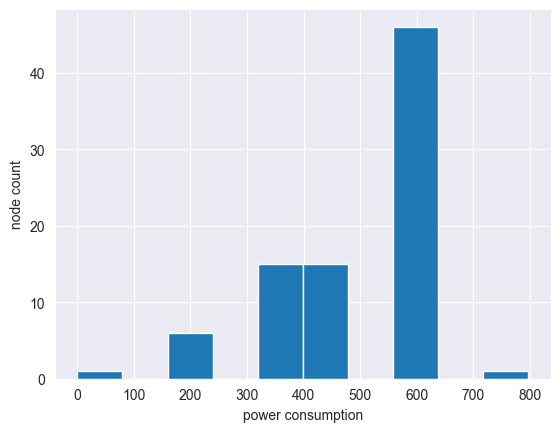

In [38]:
df_stats["latency_distribution"].hist()
plt.xlabel("power consumption")
plt.ylabel("node count")
# plt.savefig(f"plots/energy/NEMO_distribution.svg", bbox_inches="tight")

In [39]:
# the adjacency matrix for the plane
df = prim_df.copy()
t_coords = coords[0::]
solver = AnnealingSolver()
route, valueBest, nCities, recordBest, recordNow = solver.solve_tsp(t_coords, df_rtt=prim_rtts)
print("wait")

i:0, t(i):10.00, valueNow:17248.0, valueBest:17184.0
i:10, t(i):9.04, valueNow:16478.0, valueBest:16456.0
i:20, t(i):8.18, valueNow:16501.0, valueBest:16456.0
i:30, t(i):7.40, valueNow:16459.0, valueBest:16447.0
i:40, t(i):6.69, valueNow:16472.0, valueBest:16447.0
i:50, t(i):6.05, valueNow:16498.0, valueBest:16447.0
i:60, t(i):5.47, valueNow:16470.0, valueBest:16447.0
i:70, t(i):4.95, valueNow:16474.0, valueBest:16445.0
i:80, t(i):4.48, valueNow:16491.0, valueBest:16445.0
i:90, t(i):4.05, valueNow:16464.0, valueBest:16445.0
i:100, t(i):3.66, valueNow:16444.0, valueBest:16444.0
i:110, t(i):3.31, valueNow:16431.0, valueBest:16431.0
i:120, t(i):2.99, valueNow:16441.0, valueBest:16418.0
i:130, t(i):2.71, valueNow:16430.0, valueBest:16418.0
i:140, t(i):2.45, valueNow:16450.0, valueBest:16418.0
i:150, t(i):2.21, valueNow:16439.0, valueBest:16418.0
i:160, t(i):2.00, valueNow:16439.0, valueBest:16418.0
i:170, t(i):1.81, valueNow:16435.0, valueBest:16418.0
i:180, t(i):1.64, valueNow:16408.0, va

In [40]:
print(route)

[73 58 65 69 51 47 35 23 22 21 29 28 34 30 27 31 25 26  3  1  7  9 11 19
 10 16 17 12 15 18 13  5  8  0  4  2  6 14 33 32 77 81 68 54 66 83 76 75
 53 80 61 78 72 45 62 57 50 60 52 56 48 70 74 49 55 82 79 59 46 71 64 36
 20 41 43 42 63 44 67 39 40 37 38 24]


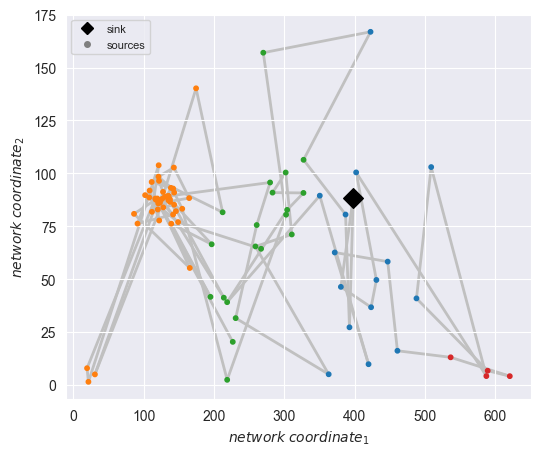

In [41]:
fig = plt.figure(figsize=(6, 5)).gca()

for i in range(0, len(route) - 1):
    point1 = coords[route[i]]
    point2 = coords[route[i + 1]]
    x_values = [point1[0], point2[0]]
    y_values = [point1[1], point2[1]]
    plt.plot(x_values, y_values, zorder=-1, color="silver", linewidth=2)

df.plot.scatter(x="x", y="y", c=colors[labels], s=10, ax=fig)
plt.scatter(coords[0, 0], coords[0, 1], s=100, marker=cmarker, color='black')

plt.legend(handles=[coordinator_label, worker_label], loc="upper left", bbox_to_anchor=(0, 1), fontsize=8)
plt.xlim(X_dim)
plt.ylim(Y_dim)
plt.xlabel('$network$ $coordinate_1$')
plt.ylabel('$network$ $coordinate_2$')
# plt.savefig(f"plots/energy/chain_50n.svg", bbox_inches="tight")
plt.show()

In [42]:
#first node is the coordinator
latency_hist = np.zeros(device_number)
received_packets_hist = np.zeros(device_number)
ind_cor = np.where(route == 0)[0][0]
print("Coordinator is on place ", ind_cor, " in route.")

for i in range(0, len(route)):
    #calculate euclidean distance which corresponds to the cost space (latency)
    dist = 0
    lat_route = []
    if i < ind_cor:
        lat_route = route[i:ind_cor + 1]
    elif i > ind_cor:
        lat_route = route[i:ind_cor - 1:-1]
    else:
        continue

    start_idx = lat_route[0]
    received_packets_hist[lat_route[1]] += 1
    for j in range(1, len(lat_route)):
        end_idx = lat_route[j]
        if prim_rtts is not None:
            dist = dist + prim_rtts.loc[start_idx, end_idx]
        else:
            dist = dist + np.linalg.norm(coords[start_idx] - coords[end_idx])
        start_idx = end_idx
    latency_hist[i] = dist

statistics = {"latency_distribution": latency_hist,
              "received_packets": received_packets_hist}
df_stats = pd.DataFrame(statistics)

Coordinator is on place  33  in route.


In [43]:
print(df_stats["received_packets"])

0     2.0
1     1.0
2     1.0
3     1.0
4     1.0
     ... 
79    1.0
80    1.0
81    1.0
82    1.0
83    1.0
Name: received_packets, Length: 84, dtype: float64


count      84.000000
mean     4262.522619
std      2649.403582
min         0.000000
25%      2095.550000
50%      4094.800000
75%      6093.425000
max      9750.300000
Name: latency_distribution, dtype: float64


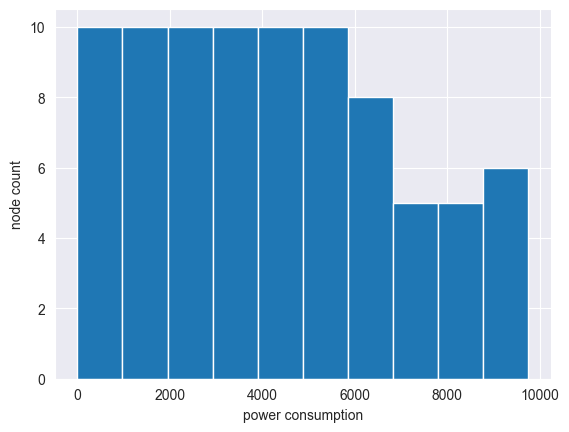

In [44]:
df_stats["latency_distribution"].hist()
plt.xlabel("power consumption")
plt.ylabel("node count")
# plt.title("Power Consumption Distribution")
# plt.savefig(f"plots/energy/chain_distribution.svg", bbox_inches="tight")
print(df_stats["latency_distribution"].describe())

count    84.000000
mean      0.988095
std       0.189740
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
Name: received_packets, dtype: float64


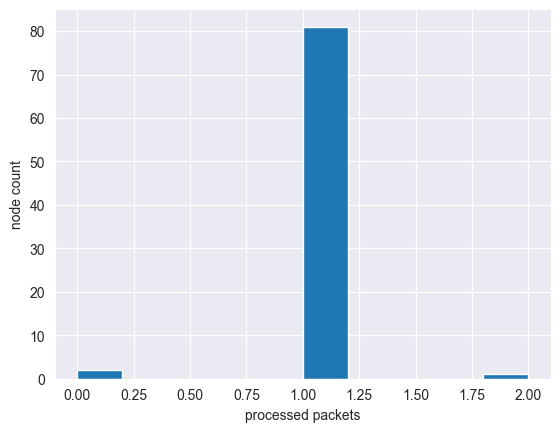

In [45]:
df_stats["received_packets"].hist()
plt.xlabel("processed packets")
plt.ylabel("node count")
# plt.title("Processed packets distribution")
# plt.savefig(f"plots/energy/chain_processed_packets_distribution.svg", bbox_inches="tight")
print(df_stats["received_packets"].describe())

eval_matrix["chain"] = df_stats.copy()

In [46]:
np.where(received_packets_hist > 1)

(array([0], dtype=int64),)

In [47]:
### Experiment 4: Calculating the minimum spanning tree like in PEDAP

In [48]:
df = prim_df.copy()
mst = prim_mst(coords, df_rtt=prim_rtts)

In [49]:
print(mst)

[-1, 0, 0, 1, 0, 2, 5, 5, 5, 16, 8, 10, 8, 10, 13, 10, 10, 16, 10, 11, 4, 7, 23, 24, 21, 5, 25, 26, 27, 26, 26, 27, 27, 28, 28, 38, 38, 38, 24, 38, 38, 42, 72, 41, 45, 65, 65, 45, 45, 65, 45, 65, 45, 45, 45, 45, 45, 45, 45, 45, 46, 45, 45, 45, 45, 37, 65, 39, 44, 65, 45, 45, 45, 45, 45, 46, 45, 47, 65, 45, 45, 45, 45, 46]


In [50]:
routes = createRoutes(mst)
print(routes[2])

[0]


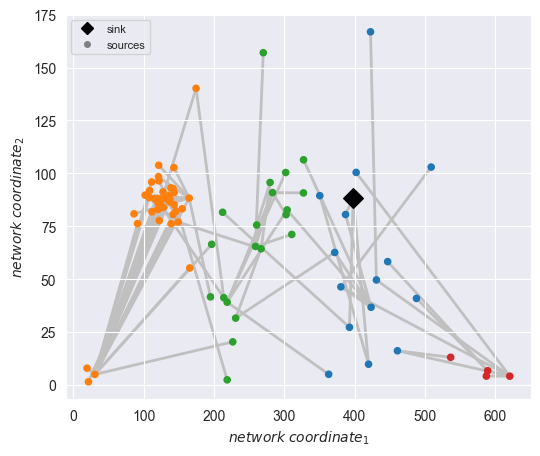

In [51]:
fig = plt.figure(figsize=(6, 5)).gca()

for i in range(1, len(mst)):
    point1 = coords[i]
    point2 = coords[mst[i]]
    x_values = [point1[0], point2[0]]
    y_values = [point1[1], point2[1]]
    plt.plot(x_values, y_values, zorder=-1, color="silver", linewidth=2)

df.plot.scatter(x="x", y="y", c=colors[labels], ax=fig)
fig.scatter(coords[0, 0], coords[0, 1], s=100, marker=cmarker, color='black')

plt.legend(handles=[coordinator_label, worker_label], loc="upper left", bbox_to_anchor=(0, 1), fontsize=8)
plt.xlim(X_dim)
plt.ylim(Y_dim)
plt.xlabel('$network$ $coordinate_1$')
plt.ylabel('$network$ $coordinate_2$')
# plt.savefig(f"plots/energy/mst.svg", bbox_inches="tight")
plt.show()

In [52]:
#first node is the coordinator
latency_hist = np.zeros(device_number)
for i in range(1, device_number):
    #calculate euclidean distance which corresponds to the cost space (latency)
    dist = 0
    lat_route = routes[i]
    start = i
    for j in range(0, len(lat_route)):
        end = lat_route[j]
        if prim_rtts is not None:
            dist = dist + prim_rtts.loc[start, end]
        else:
            dist = dist + np.linalg.norm(coords[start] - coords[end])
        start = end
    latency_hist[i] = dist

received_packets_hist = np.zeros(device_number)
for i in range(1, device_number):
    received_packets_hist[mst[i]] += 1

statistics = {"latency_distribution": latency_hist,
              "received_packets": received_packets_hist}
df_stats = pd.DataFrame(statistics)

count      84.000000
mean     1442.890476
std       589.416271
min         0.000000
25%       975.400000
50%      1558.800000
75%      1948.000000
max      2532.300000
Name: latency_distribution, dtype: float64


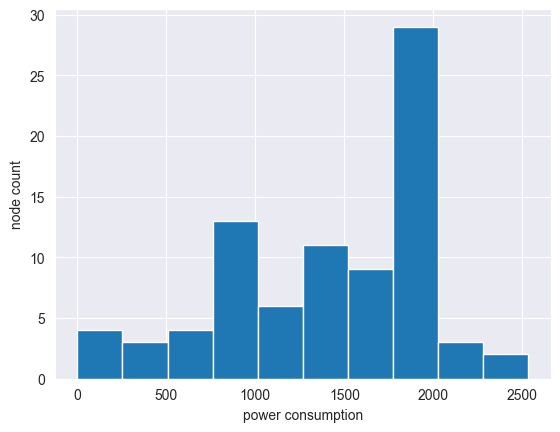

In [53]:
df_stats["latency_distribution"].hist()
plt.xlabel("power consumption")
plt.ylabel("node count")
# plt.title("Power Consumption Distribution")
# plt.savefig(f"plots/energy/mst_distribution.svg", bbox_inches="tight")
print(df_stats["latency_distribution"].describe())

Distribution of workload:  34.5238 %


Text(0, 0.5, 'processed packets')

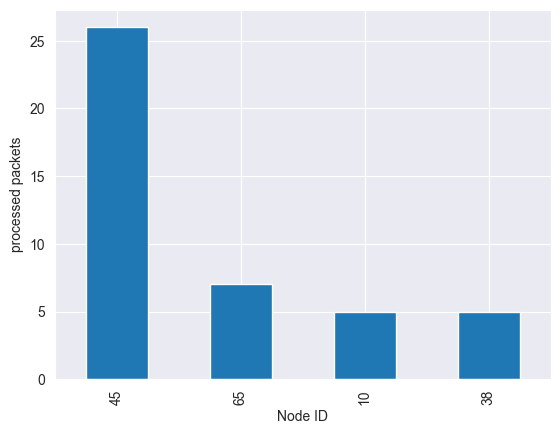

In [54]:
df_packets = df_stats.loc[df_stats["received_packets"] > 0]["received_packets"].sort_values(ascending=False)
print("Distribution of workload: ", round(len(df_packets) / device_number * 100, 4), "%")

df_packets = df_packets.head(int(round(device_number * 0.05)))
df_packets.plot.bar()

plt.xlabel("Node ID")
plt.ylabel("processed packets")
# plt.title("Processed packets distribution")
# plt.savefig(f"plots/energy/mst_processed_packets_distribution.svg", bbox_inches="tight")

In [55]:
eval_matrix["mst"] = df_stats.copy()

In [56]:
eval_matrix.keys()

dict_keys(['dt', 'leach', 'nemo_dc_weight_1', 'nemo_dc_weight_2', 'nemo_dc_weight', 'chain', 'mst'])

In [57]:
aggregation_fams = ["dt", "leach", "mst", "chain"]
heterogen_appr = ['nemo_dc_weight_1', 'nemo_dc_weight_2', 'nemo_dc_weight']

#### Latency

In [58]:
heterogen_appr

['nemo_dc_weight_1', 'nemo_dc_weight_2', 'nemo_dc_weight']

In [59]:
colors_eval, light_colors_eval, palette_eval = util.get_color_list(11)

eval_colors = {
    "dt": colors_eval[0],
    "leach": colors_eval[1],
    "mst": colors_eval[2],
    "chain": colors_eval[3],
    "nemo": colors_eval[4],
    "nemo_base": colors_eval[4],
    "nemo_dc_base": colors_eval[4],
    "NEMO_base": colors_eval[4],
    "nemo_rc": colors_eval[5],
    "nemo_rc_base": colors_eval[5],
    "nemo (rdm groups)_base": colors_eval[5],
    "NEMO+redistribution": colors_eval[6],
    "nemo_pen": colors_eval[7],
    "nemo_pen_base": colors_eval[8],
    "nemo_dc_weight_1": colors_eval[6],
    "nemo_dc_weight_2": colors_eval[9],
    "nemo_dc_weight": colors_eval[10]
}

renaming_dict = {
    "nemo_dc_weight_1": "nemo (w=1,",
    "nemo_dc_weight_2": "nemo (w=2,",
    "nemo_dc_weight": "nemo (w=ln[1, 50],",
    "capacity_100": "m=" + first_med_label,
    # "capacity_1": "m=" + last_med_label
}

In [60]:
eval_matrix["dt"]["latency_distribution"].mean()

449.1928571428571

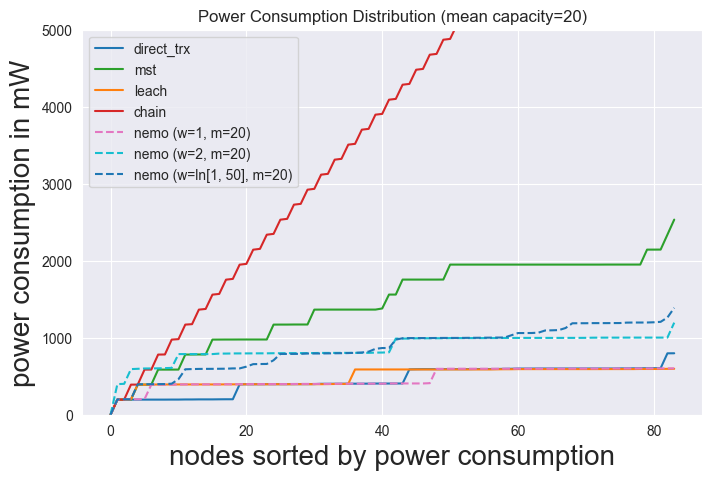

Means:  {'dt': 449.19, 'mst': 1442.89, 'leach': 493.47, 'chain': 4262.52, 'nemo (w=1, m=20)': 466.47, 'nemo (w=2, m=20)': 862.99, 'nemo (w=ln[1, 50], m=20)': 854.06}
Quantiles:  {'dt': 599.68, 'mst': 1948.5, 'leach': 591.2, 'chain': 8134.47, 'nemo (w=1, m=20)': 598.98, 'nemo (w=2, m=20)': 999.6, 'nemo (w=ln[1, 50], m=20)': 1188.91}


In [77]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5), sharey="all")
quant_dict = {}
mean_dict = {}

#plot baselines
for l in ["dt", "mst", "leach", "chain"]:
# for l in ["dt", "mst", "leach"]:

    orl = l
    sv = eval_matrix[l]["latency_distribution"].sort_values()
    #print("Mean latency ", l, ": ", round(eval_matrix[l]["latency_distribution"].mean(), 2))
    quant_dict[l] = round(eval_matrix[l]["latency_distribution"].quantile(0.9), 2)
    mean_dict[l] = round(eval_matrix[l]["latency_distribution"].mean(), 2)

    if l == "dt":
        l = "direct_trx"
    sv.plot(ax=ax1, linestyle="-", use_index=False, label=l, color=eval_colors[orl])

for approach in heterogen_appr:
    cl = approach
    emat = eval_matrix[approach]

    for capacity, df in emat.items():
        if capacity not in ["capacity_100"]:
            continue
        l = renaming_dict[approach] + " " + renaming_dict[capacity] + ")"

        sv = df["latency_distribution"]
        sv = sv.sort_values()

        sv_quant = round(sv.quantile(0.9), 2)
        sv_mean = round(sv.mean(), 2)

        quant_dict[l] = sv_quant
        mean_dict[l] = sv_mean
        sv.plot(ax=ax1, use_index=False, label=l, color=eval_colors[cl], linestyle="--")

ax1.set_xlabel('nodes sorted by power consumption')
ax1.set_ylabel('power consumption in mW')

ax1.legend(loc="upper left", prop={'size': 10})
# Display a figure.
plt.ylim([0, 5000])

ax1.yaxis.label.set_size(20)
ax1.xaxis.label.set_size(20)

plt.savefig(f"plots/energy/eval_latency.svg")

ax1.set_title('Power Consumption Distribution (mean capacity=' + str(avg) + ")")
plt.show()
print("Means: ", mean_dict)
print("Quantiles: ", quant_dict)

#### Heterogeneity

In [62]:
aggregation_fams

['dt', 'leach', 'mst', 'chain']

In [63]:
eval_matrix_load = eval_matrix.copy()
eval_matrix_load.pop("nemo_dc_weight_2")
eval_matrix_load.pop("nemo_dc_weight")
eval_matrix_load.keys()

dict_keys(['dt', 'leach', 'nemo_dc_weight_1', 'chain', 'mst'])

In [64]:
load_dict = {}
nn_dict = {}

for k, df in eval_matrix_load.items():
    if k in aggregation_fams:
        slot_list = []
        nn_list = []
        if k == "leach":
            all_slot_lists = []
            all_nn_lists = []
            for df in df_stats_leach:
                tmp_slot_list = []
                tmp_nn_list = []
                for colname in slot_columns:
                    df["av_capacity"] = prim_df[colname] - df["received_packets"]
                    tmp_df_sl = df[df["av_capacity"] < 0]
                    tmp_df_nn = df[df["av_capacity"] > 0]
                    tmp_slot_list.append(tmp_df_sl["av_capacity"].count())
                    tmp_nn_list.append(tmp_df_nn["av_capacity"].count())
                all_slot_lists.append(np.array(tmp_slot_list))
                all_nn_lists.append(np.array(tmp_nn_list))
            slot_list = (sum(all_slot_lists) / leach_runs).tolist()
            nn_list = (sum(all_nn_lists) / leach_runs).tolist()
        else:
            for colname in slot_columns:
                df["av_capacity"] = prim_df[colname] - df["received_packets"]
                tmp_df_sl = df[df["av_capacity"] < 0]
                tmp_df_nn = df[df["av_capacity"] > 0]
                slot_list.append(tmp_df_sl["av_capacity"].count())
                nn_list.append(tmp_df_nn["av_capacity"].count())
        load_dict[k] = slot_list
        nn_dict[k] = nn_list

In [65]:
load_dict

{'dt': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'leach': [1.0, 1.0, 1.05, 1.05, 0.95, 1.1, 1.1, 1.05, 1.25, 1.4, 1.95, 3.2],
 'chain': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8],
 'mst': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3]}

In [66]:
load_dict = {}
nn_dict = {}

for k, df in eval_matrix_load.items():
    if k in aggregation_fams:
        slot_list = []
        nn_list = []
        if k == "leach":
            all_slot_lists = []
            all_nn_lists = []
            for df in df_stats_leach:
                tmp_slot_list = []
                tmp_nn_list = []
                for colname in slot_columns:
                    df["av_capacity"] = prim_df[colname] - df["received_packets"]
                    tmp_df_sl = df[df["av_capacity"] < 0]
                    tmp_df_nn = df[df["av_capacity"] > 0]
                    tmp_slot_list.append(tmp_df_sl["av_capacity"].count())
                    tmp_nn_list.append(tmp_df_nn["av_capacity"].count())
                all_slot_lists.append(np.array(tmp_slot_list))
                all_nn_lists.append(np.array(tmp_nn_list))
            slot_list = (sum(all_slot_lists) / leach_runs).tolist()
            nn_list = (sum(all_nn_lists) / leach_runs).tolist()
        else:
            for colname in slot_columns:
                df["av_capacity"] = prim_df[colname] - df["received_packets"]
                tmp_df_sl = df[df["av_capacity"] < 0]
                tmp_df_nn = df[df["av_capacity"] > 0]
                slot_list.append(tmp_df_sl["av_capacity"].count())
                nn_list.append(tmp_df_nn["av_capacity"].count())
        load_dict[k] = slot_list
        nn_dict[k] = nn_list

for k, mat in eval_matrix_load.items():
    if k in heterogen_appr:
        slot_list = []
        nn_list = []
        for colname in slot_columns:
            df = mat[colname]
            df["av_capacity"] = prim_df[colname] - df["received_packets"]
            tmp_df_sl = df[df["av_capacity"] < 0]
            tmp_df_nn = df[df["av_capacity"] >= 0]
            slot_list.append(tmp_df_sl["av_capacity"].count())
            nn_list.append(tmp_df_nn["av_capacity"].count())
        load_dict[k] = slot_list
        nn_dict[k] = nn_list

#for k, mat in eval_matrix.items():
#    if k in heterogen_appr:
#        slot_list = []
#        nn_list = []
#        for colname in slot_columns:
#            df = mat["base"]
#            df["av_capacity"] = prim_df[colname] - df["received_packets"]
#            tmp_df_sl = df[df["av_capacity"] < 0]
#            tmp_df_nn = df[df["av_capacity"] >= 0]
#            slot_list.append(tmp_df_sl["av_capacity"].count())
#            nn_list.append(tmp_df_nn["av_capacity"].count())
#        load_dict[k + "_base"] = slot_list
#        nn_dict[k + "_base"] = nn_list

In [67]:
load_dict.keys()

dict_keys(['dt', 'leach', 'chain', 'mst', 'nemo_dc_weight_1'])

In [68]:
agg_arr1 = []
for fam in load_dict.keys():
    agg_arr1.append(load_dict[fam])
    print("Fam: ", fam)
    print(load_dict[fam])

#agg_arr2 = []
#for fam in eval_matrix_load.keys():
#    agg_arr2.append(load_dict[fam + "_base"])
#mr = np.mean(np.array(agg_arr2), axis=0)
#load_dict["NEMO_base"] = mr
#print(mr)

Fam:  dt
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Fam:  leach
[1.0, 1.0, 1.05, 1.05, 0.95, 1.1, 1.1, 1.05, 1.25, 1.4, 1.95, 3.2]
Fam:  chain
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8]
Fam:  mst
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3]
Fam:  nemo_dc_weight_1
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


dt [20.  20.5 20.  20.  20.  20.  18.5 18.  18.5 16.  13.  11. ]
dt [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
leach [20.  20.5 20.  20.  20.  20.  18.5 18.  18.5 16.  13.  11. ]
leach [1.0, 1.0, 1.05, 1.05, 0.95, 1.1, 1.1, 1.05, 1.25, 1.4, 1.95, 3.2]
chain [20.  20.5 20.  20.  20.  20.  18.5 18.  18.5 16.  13.  11. ]
chain [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8]
mst [20.  20.5 20.  20.  20.  20.  18.5 18.  18.5 16.  13.  11. ]
mst [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3]
nemo_dc_weight_1 [20.  20.5 20.  20.  20.  20.  18.5 18.  18.5 16.  13.  11. ]
nemo_dc_weight_1 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


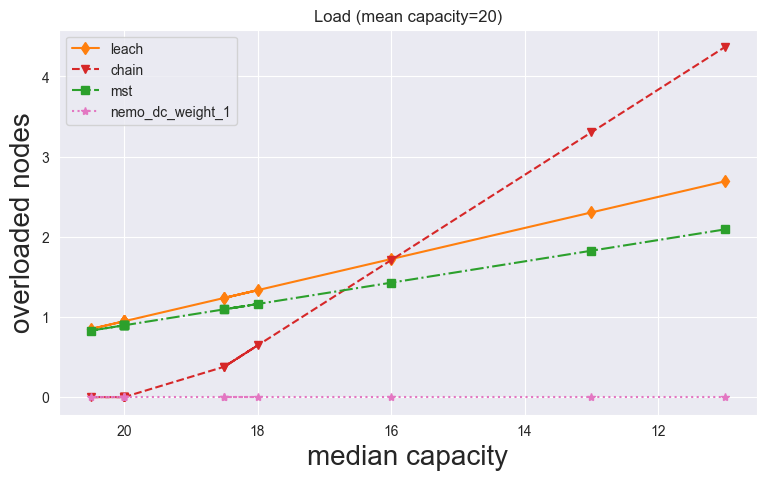

In [69]:
fig, ax = plt.subplots(figsize=(9, 5))
markers = ["d", "v", "s", "*", "^", "d", "v", "s", "*", "^"]
styles = ["-", "--", "-.", ":", "-.", "-"]
i = 0
for fam in load_dict.keys():
    vals = load_dict[fam]
    evcol = fam
    print(fam, medians)
    print(fam, vals)
    m, b = np.polyfit(medians, vals, 1)
    if fam == "dt":
        fam = "direct_trx"
        continue
    if fam == "nemo_dc":
        fam = "nemo"
    ax.plot(medians, (m * medians + b).clip(min=0), marker=markers[i], label=fam, linestyle=styles[i],
            color=eval_colors[evcol])
    i = i + 1

ax.invert_xaxis()
ax.set_xlabel("median capacity")
ax.set_ylabel("overloaded nodes")
#ax.set_yscale('log')
ax.legend()

ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

# plt.savefig(f"plots/energy/eval_load_abs.svg")
ax.set_title("Load (mean capacity=" + str(avg) + ")")
plt.show()

In [70]:
load_dict.keys()

dict_keys(['dt', 'leach', 'chain', 'mst', 'nemo_dc_weight_1'])

leach - d #ff7f0e : [12.5, 12.5, 13.125, 13.125, 11.875, 13.750000000000002, 13.750000000000002, 13.125, 15.625, 17.5, 24.375, 40.0]
chain -- v #d62728 : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.75609756097561]
mst -. s #2ca02c : [2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 2.4096385542168677, 7.228915662650602]
nemo_dc_weight_1 : * #e377c2 : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


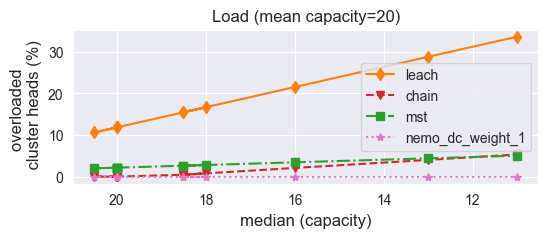

In [71]:
fig, ax = plt.subplots(figsize=(6, 2))
markers = ["d", "v", "s", "*", "^", "d", "v", "s", "*", "^"]
styles = ["-", "--", "-.", ":", "-.", "-"]
i = 0
for fam in load_dict.keys():
    vals = load_dict[fam]
    evcol = fam
    if fam == "dt":
        fam = "direct_trx"
        vals = [100 for x in vals]
        continue
    if fam == "leach":
        vals = [x / num_leach_clusters * 100 for x in vals]
    if fam == "mst":
        agg_points = (device_number - 1) / 2
        vals = [x / agg_points * 100 for x in vals]
    if fam == "chain":
        agg_points = device_number - 2
        vals = [x / agg_points * 100 for x in vals]
    if fam == "nemo_dc":
        fam = "nemo"
    m, b = np.polyfit(medians, vals, 1)
    print(fam, styles[i], markers[i], eval_colors[evcol], ":", vals)
    ax.plot(medians, (m * medians + b).clip(min=0), marker=markers[i], label=fam, linestyle=styles[i],
            color=eval_colors[evcol])
    i = i + 1

ax.invert_xaxis()
ax.set_xlabel("median (capacity)")
ax.set_ylabel("overloaded \n cluster heads (%)")
#ax.set_yscale('log')
ax.legend()

ax.yaxis.label.set_size(12)
ax.xaxis.label.set_size(12)

# plt.savefig(f"plots/energy/eval_load_perc.svg")
ax.set_title("Load (mean capacity=" + str(avg) + ")")
plt.show()

In [72]:
quant_dict

{'dt': 599.68,
 'mst': 1948.5,
 'leach': 591.2,
 'chain': 8134.47,
 'nemo (w=1, m=20)': 598.98,
 'nemo (w=2, m=20)': 999.6,
 'nemo (w=ln[1, 50], m=20)': 1188.91}

In [73]:
mean_dict

{'dt': 449.19,
 'mst': 1442.89,
 'leach': 493.47,
 'chain': 4262.52,
 'nemo (w=1, m=20)': 466.47,
 'nemo (w=2, m=20)': 862.99,
 'nemo (w=ln[1, 50], m=20)': 854.06}